In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import  ast
import streamlit as st
import os

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Cargamos el conjunto de datos y permitimos poder ver todas las columnas del mismo

df_movies = pd.read_csv("movies_metadata.csv", low_memory = False)
pd.set_option('display.max_columns', None)
df_movies.head(2)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


In [4]:
df_movies['runtime'].unique()

array([8.100e+01, 1.040e+02, 1.010e+02, 1.270e+02, 1.060e+02, 1.700e+02,
       9.700e+01, 1.300e+02, 8.800e+01, 7.800e+01, 1.920e+02, 1.190e+02,
       1.780e+02, 1.360e+02, 9.800e+01, 9.000e+01, 1.030e+02, 1.050e+02,
       1.240e+02, 1.320e+02, 1.110e+02, 1.120e+02, 1.230e+02, 1.000e+02,
       1.080e+02, 9.900e+01, 1.290e+02, 5.000e+01, 8.900e+01, 1.210e+02,
       1.220e+02, 5.100e+01, 1.170e+02, 1.160e+02, 9.600e+01, 9.300e+01,
       9.500e+01, 1.150e+02, 1.370e+02, 9.200e+01, 8.500e+01, 9.100e+01,
       1.750e+02, 8.700e+01, 7.000e+01, 1.180e+02, 1.020e+02, 1.350e+02,
       1.100e+02, 1.770e+02, 1.140e+02, 1.130e+02, 8.600e+01, 1.250e+02,
       1.400e+02, 1.390e+02, 8.200e+01, 8.300e+01, 1.280e+02, 1.090e+02,
       8.000e+01, 1.340e+02, 1.070e+02, 9.400e+01, 1.450e+02, 7.300e+01,
       0.000e+00, 7.700e+01, 1.710e+02, 1.330e+02, 1.540e+02, 1.620e+02,
       1.420e+02, 1.260e+02, 1.410e+02, 1.800e+02, 1.910e+02, 6.100e+01,
       8.400e+01, 1.440e+02, 1.310e+02, 1.380e+02, 

In [5]:
print(f" El conjunto de datos cuenta con {df_movies.shape[0]} filas y {df_movies.shape[1]} columnas")

 El conjunto de datos cuenta con 45466 filas y 24 columnas


In [6]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
# Se revisa las columnas numericas y sus datos estadisticos transpuestos para mejor comprension

df_movies.describe().T

,count,mean,std,min,25%,50%,75%,max
revenue,45460.0,1.120935e+07,6.433225e+07,0.0,0.0,0.0,0.0,2.787965e+09
runtime,45203.0,9.412820e+01,3.840781e+01,0.0,85.0,95.0,107.0,1.256000e+03
vote_average,45460.0,5.618207e+00,1.924216e+00,0.0,5.0,6.0,6.8,1.000000e+01
vote_count,45460.0,1.098973e+02,4.913104e+02,0.0,3.0,10.0,34.0,1.407500e+04


In [8]:
# Proporción de nulos por columna

null_proportions = (
    df_movies.isnull()
    .mean()
    .mul(100)
)
print(null_proportions[null_proportions > 0].sort_values(ascending=False))

belongs_to_collection    90.115691
homepage                 82.883913
tagline                  55.104914
overview                  2.098271
poster_path               0.848986
runtime                   0.578454
release_date              0.191352
status                    0.191352
imdb_id                   0.037391
original_language         0.024194
revenue                   0.013197
title                     0.013197
video                     0.013197
vote_average              0.013197
spoken_languages          0.013197
vote_count                0.013197
popularity                0.010997
production_companies      0.006598
production_countries      0.006598
dtype: float64


In [9]:
# Generamos una copia para evitar modificar el conjunto de datos original

df = df_movies.copy()

### **Tratamiento de valores nulos**

In [10]:
# Categóricas / texto → imputar con string explícito

df['belongs_to_collection'] = df['belongs_to_collection'].fillna('No pertenece a colección')
df['homepage'] = df['homepage'].fillna('Sin página oficial')
df['tagline'] = df['tagline'].fillna('Sin tagline')
df['overview'] = df['overview'].fillna('Sin descripción disponible')
df['poster_path'] = df['poster_path'].fillna('No disponible')
df['status'] = df['status'].fillna(df['status'].mode()[0])          
df['original_language'] = df['original_language'].fillna('xx') # → usaremos algo generico para su relleno
df['spoken_languages'] = df['spoken_languages'].fillna('[]')

In [11]:
# Numéricas → mediana (robusta a outliers)

num_cols_median = ['runtime', 'vote_average', 'vote_count', 'popularity', 'revenue']
for col in num_cols_median:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [12]:
# Otras con muy pocos nulos → eliminamos filas (pérdida aceptable y dentro de parametros)

cols_low_null = ['title', 'imdb_id', 'production_companies', 'production_countries']
df = df.dropna(subset=cols_low_null)

In [13]:
# Verificación final post-limpieza

print("Nulos restantes:", df.isnull().sum()[df.isnull().sum() > 0])
print(f"Nueva forma del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")

Nulos restantes: release_date    81
dtype: int64
Nueva forma del dataset: 45443 filas y 24 columnas


### **Conversión de tipos de datos**

In [14]:
#  Convertir columnas numéricas que siguen como object
numeric_float = ['popularity', 'revenue', 'vote_average', 'vote_count']
numeric_int_nullable = ['budget', 'runtime']

for col in numeric_float:
    df[col] = pd.to_numeric(df[col], errors='coerce')   

for col in numeric_int_nullable:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

In [15]:
# Fechas

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_date'] = df['release_date'].fillna(pd.to_datetime('1900-01-01'))

In [16]:
# Columnas categóricas de baja cardinalidad

cat_cols = ['original_language', 'status', 'adult', 'video']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [17]:
# ID principal: intentar convertir a int (si no hay duplicados o basura)

df['id'] = pd.to_numeric(df['id'], errors='coerce').astype('Int64')

In [18]:
# Parsear columnas que son JSON-like
# Ejemplo: extraer solo nombres de géneros como lista

def extract_genres(x):
    try:
        genres_list = ast.literal_eval(x) if isinstance(x, str) else x
        return [g['name'] for g in genres_list] if isinstance(genres_list, list) else []
    except:
        return []

df['genres_list'] = df['genres'].apply(extract_genres)

In [19]:
print(f"Tipos de datos después de conversión:{df.dtypes}")

Tipos de datos después de conversión:adult                          category
belongs_to_collection            object
budget                            Int64
genres                           object
homepage                         object
id                                Int64
imdb_id                          object
original_language              category
original_title                   object
overview                         object
popularity                      float64
poster_path                      object
production_companies             object
production_countries             object
release_date             datetime64[ns]
revenue                         float64
runtime                           Int64
spoken_languages                 object
status                         category
tagline                          object
title                            object
video                          category
vote_average                    float64
vote_count                      float64
gen

### **Eliminación de duplicados**

In [20]:
# Duplicados por 'id' (clave principal → no afecta listas)
duplicated_id = df.duplicated(subset=['id']).sum()
print(f"Duplicados por 'id': {duplicated_id}")

# Por título + año
df['release_year'] = df['release_date'].dt.year
duplicated_title_year = df.duplicated(subset=['title', 'release_year']).sum()
print(f"Duplicados por título + año: {duplicated_title_year}")

# Eliminar por 'id' (priorizando mayor vote_count)
if duplicated_id > 0:
    df = df.sort_values('vote_count', ascending=False).drop_duplicates(subset=['id'], keep='first')
    print("→ Eliminados Duplicados por 'id'")

# Eliminar duplicados titulo y año de lanzamiento
if duplicated_title_year > 0:
    df = df.sort_values('vote_count', ascending=False).drop_duplicates(subset=['title', 'release_year'], keep='first')
    print(f"→ Eliminados {duplicated_title_year} duplicados por título + año")

Duplicados por 'id': 30
Duplicados por título + año: 81
→ Eliminados Duplicados por 'id'
→ Eliminados 81 duplicados por título + año


### **EDA - Análisis univariado**

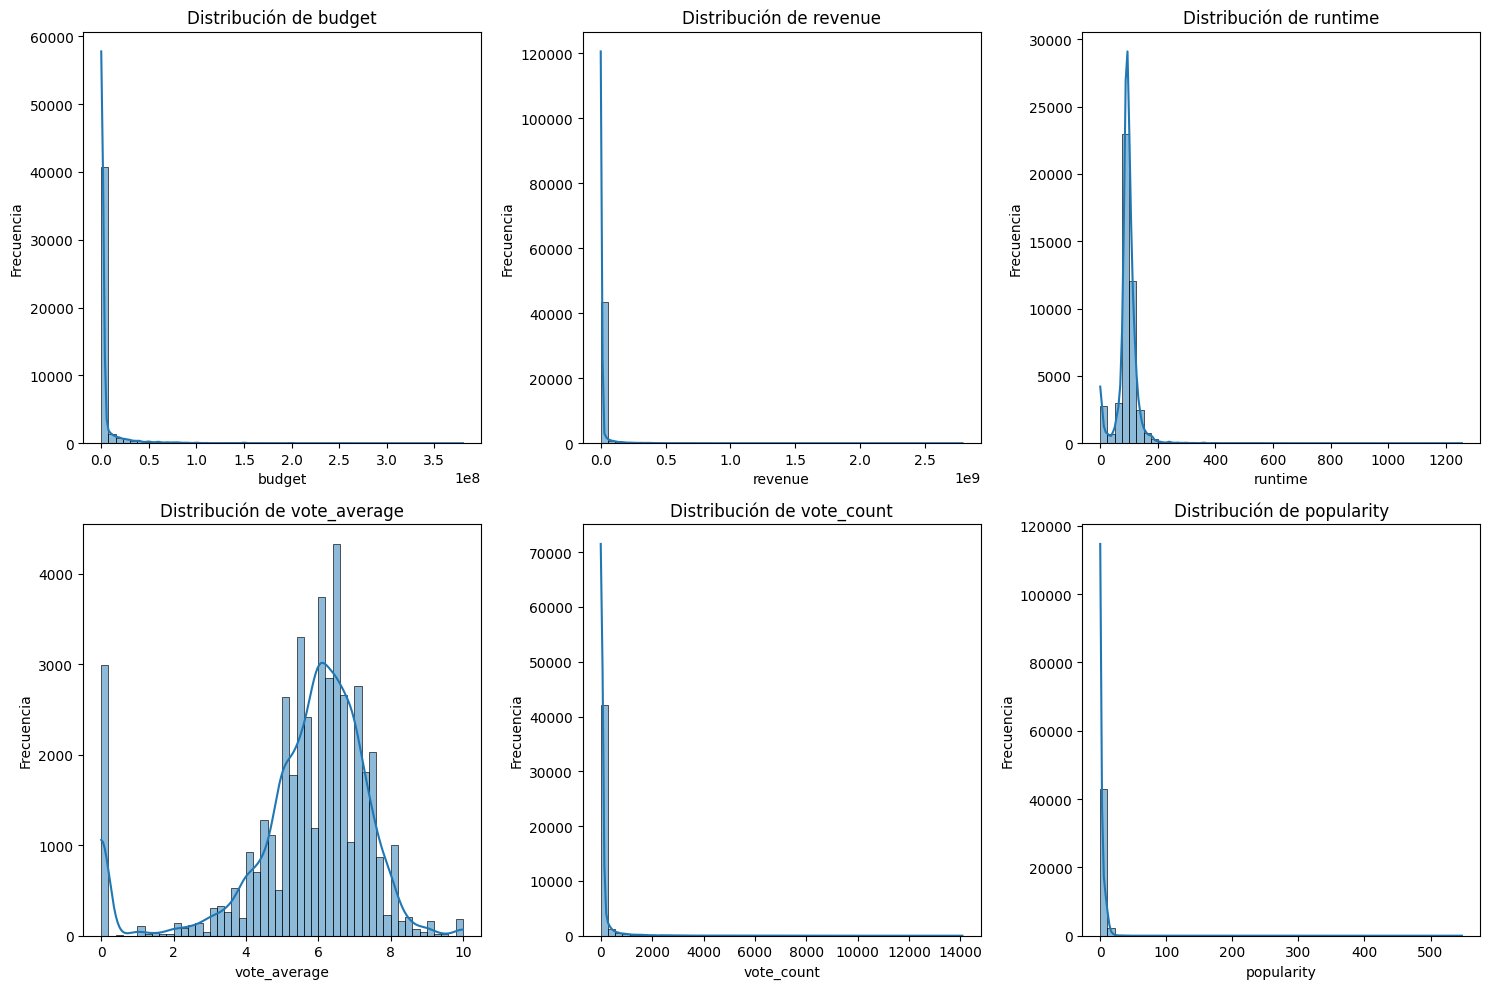

In [21]:
# Variables numéricas clave 

num_vars = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.histplot(data=df, x=var, kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

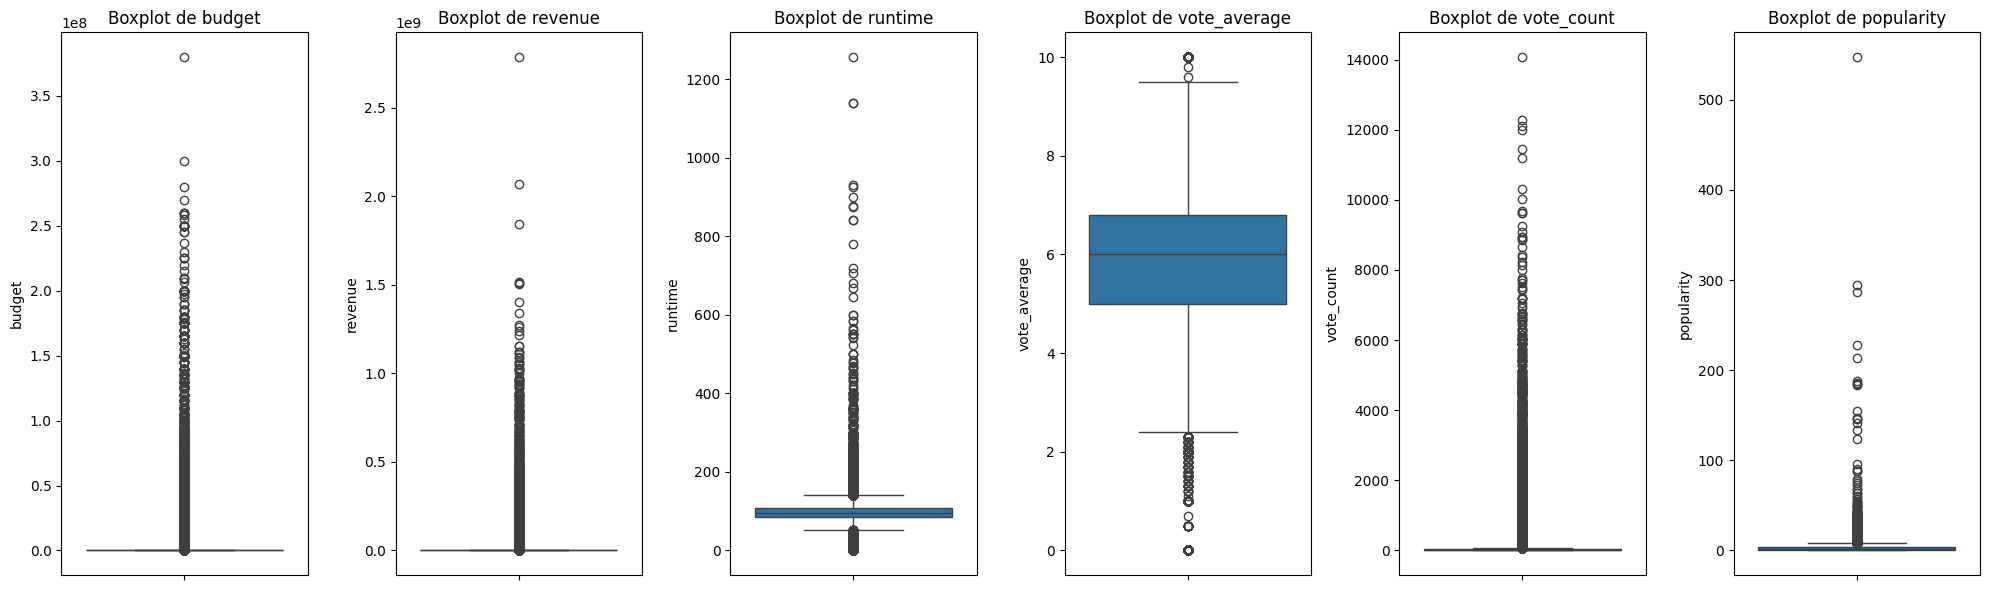

In [22]:
# Boxplots para detectar outliers

fig, axes = plt.subplots(1, len(num_vars), figsize=(20, 6))
for i, var in enumerate(num_vars):
    sns.boxplot(y=df[var], ax=axes[i])
    axes[i].set_title(f'Boxplot de {var}')
plt.tight_layout()
plt.show()

In [23]:
# Variables categóricas / conteos rápidos

print("\nTop 10 idiomas originales:")
print(df['original_language'].value_counts().head(10))

print("\nEstados de las películas (status):")
print(df['status'].value_counts())

print("\n¿Cuántas son para adultos (adult)?")
print(df['adult'].value_counts(normalize=True) * 100)


Top 10 idiomas originales:
original_language
en    32203
fr     2435
it     1529
ja     1344
de     1076
es      992
ru      825
hi      507
ko      444
zh      408
Name: count, dtype: int64

Estados de las películas (status):
status
Released           45000
Rumored              227
Post Production       98
In Production         20
Planned               15
Canceled               2
Name: count, dtype: int64

¿Cuántas son para adultos (adult)?
adult
False    99.98016
True      0.01984
Name: proportion, dtype: float64


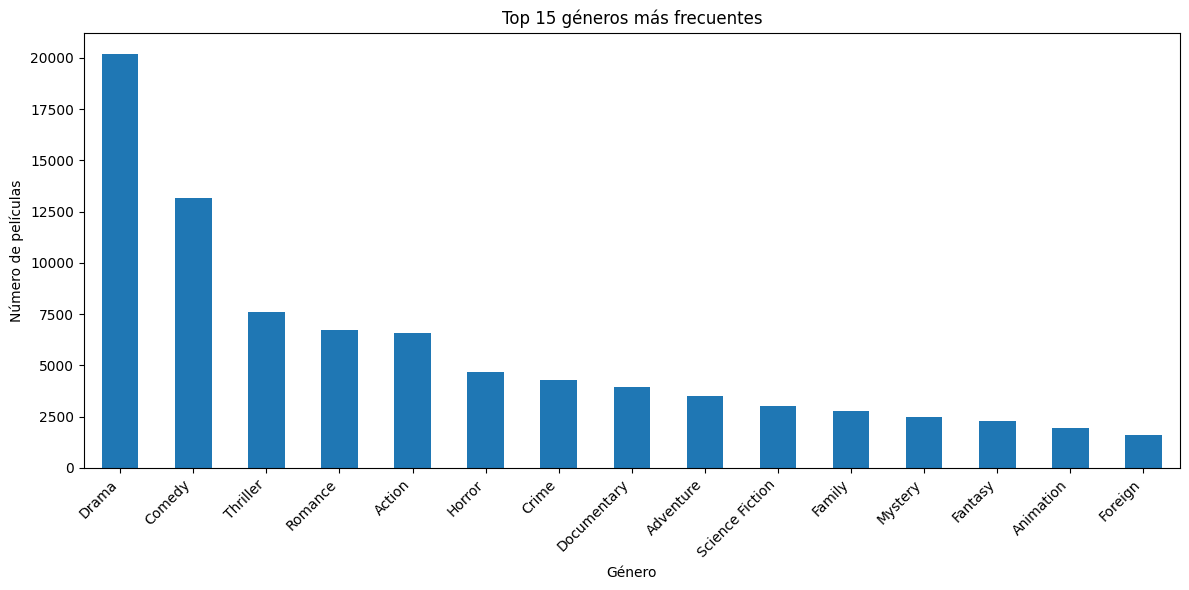

In [24]:
# Géneros más frecuentes

from collections import Counter


all_genres = [genre for sublist in df['genres_list'] for genre in sublist]
genre_counts = Counter(all_genres)
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar')
plt.title('Top 15 géneros más frecuentes')
plt.xlabel('Género')
plt.ylabel('Número de películas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Estadísticas rápidas numéricas univariadas (sin gráficos)

num_vars = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']

print("Resumen numérico:")
print(df[num_vars].describe())

print("\nPorcentaje de valores cero o muy bajos:")
for col in ['budget', 'revenue', 'vote_count']:
    zeros = (df[col] == 0).mean() * 100
    print(f"{col}: {zeros:.2f}% en 0")

print("\nOutliers potenciales en runtime:")
print("Runtime > 300 min:", (df['runtime'] > 300).sum())
print("Runtime > 1000 min:", (df['runtime'] > 1000).sum())

Resumen numérico:
                budget       revenue    runtime  vote_average    vote_count  \
count          45362.0  4.536200e+04    45362.0  45362.000000  45362.000000   
mean    4230988.443256  1.122969e+07  94.135245      5.619084    110.086725   
std    17440854.710801  6.439888e+07  38.308937      1.923307    491.818838   
min                0.0  0.000000e+00        0.0      0.000000      0.000000   
25%                0.0  0.000000e+00       85.0      5.000000      3.000000   
50%                0.0  0.000000e+00       95.0      6.000000     10.000000   
75%                0.0  0.000000e+00      107.0      6.800000     34.000000   
max        380000000.0  2.787965e+09     1256.0     10.000000  14075.000000   

         popularity  
count  45362.000000  
mean       2.923331  
std        6.010253  
min        0.000000  
25%        0.386268  
50%        1.128271  
75%        3.682042  
max      547.488298  

Porcentaje de valores cero o muy bajos:
budget: 80.44% en 0
revenue: 83

In [26]:
# Filtro conservador para EDA y modelado posterior
df_clean = df.copy()

# Solo películas Released
df_clean = df_clean[df_clean['status'] == 'Released']

# Runtime razonable (eliminar outliers extremos y 0s raros)
df_clean = df_clean[(df_clean['runtime'] >= 10) & (df_clean['runtime'] <= 400)]

# Películas con al menos 5 votos (para vote_average más confiable)
df_clean = df_clean[df_clean['vote_count'] >= 5]

# Tratamiento de budget
df_clean = df_clean[df_clean['budget'] > 0]

print(f"Forma original: {df.shape}")
print(f"Forma después de filtros básicos: {df_clean.shape}")
print(f"Pérdida: {len(df) - len(df_clean)} filas ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

Forma original: (45362, 26)
Forma después de filtros básicos: (8149, 26)
Pérdida: 37213 filas (82.04%)


### **EDA - Análisis bivariado**

In [27]:
# Renombramos el conjunto de datos, para saber cuales son los datos limpios luego de las transformaciones.

df_clean = df.copy()

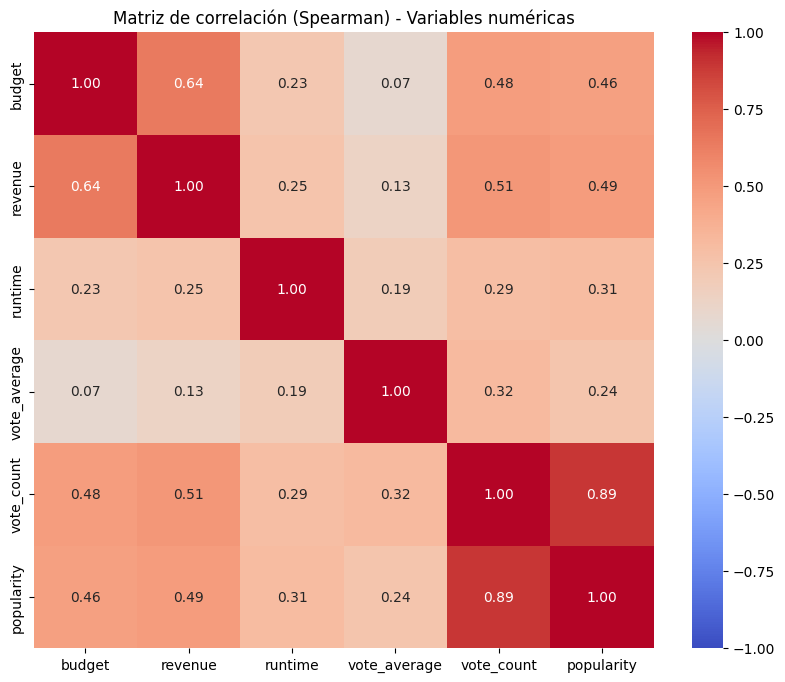

In [28]:
# Matriz de correlación (solo numéricas)

num_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']
corr = df_clean[num_cols].corr(method='spearman')  # Spearman mejor para datos sesgados

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de correlación (Spearman) - Variables numéricas')
plt.show()

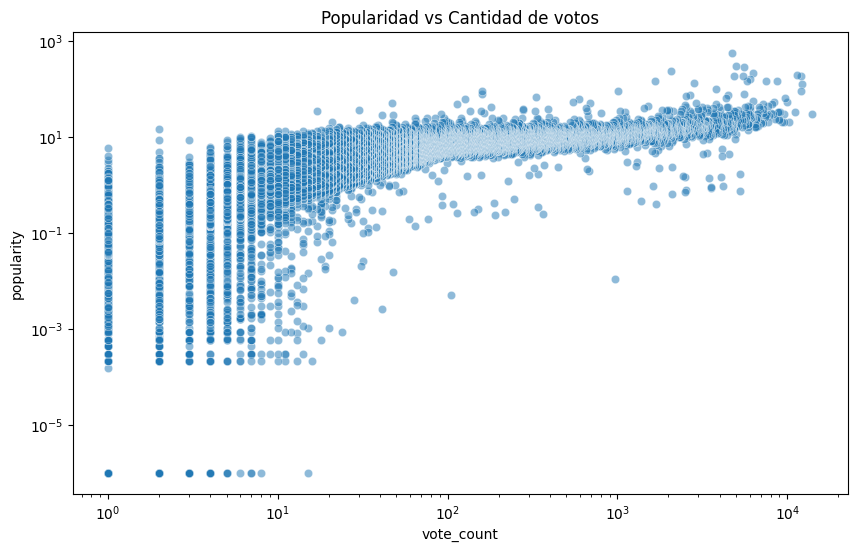

In [29]:
# Scatter: popularity vs vote_count

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='vote_count', y='popularity', alpha=0.5)
plt.title('Popularidad vs Cantidad de votos')
plt.xscale('log')
plt.yscale('log')
plt.show()

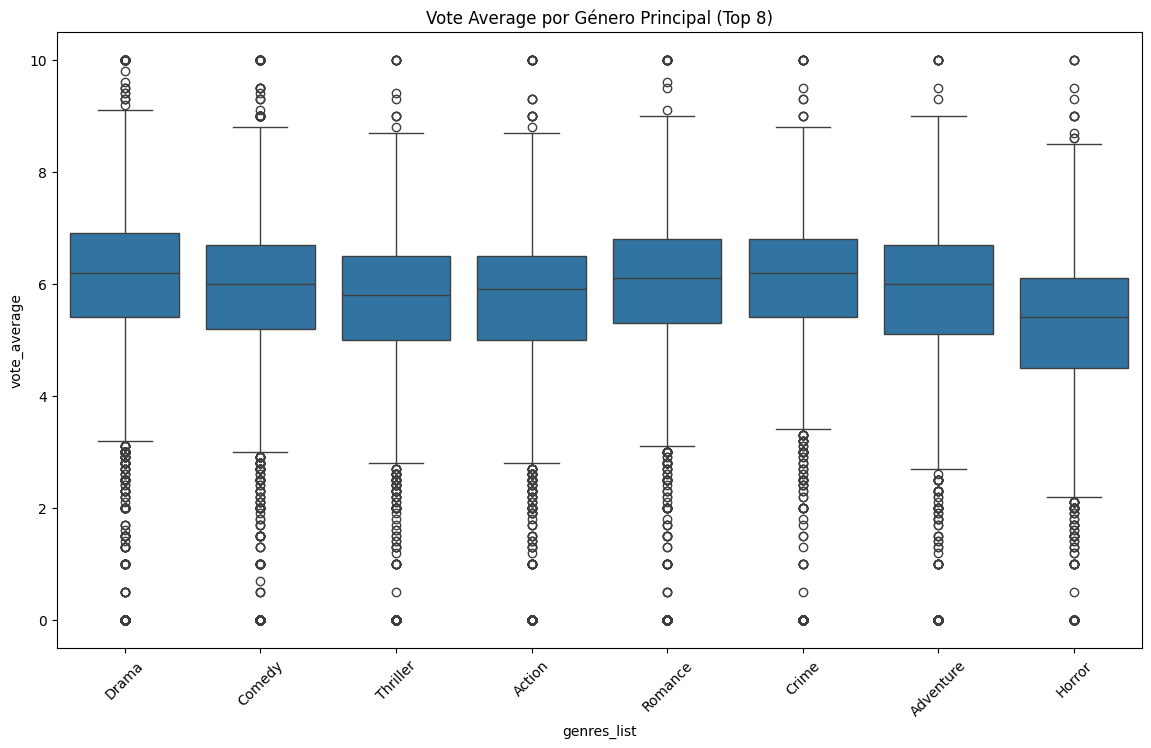

In [30]:
# Boxplot: vote_average por top géneros (seleccionamos 8 más frecuentes)

top_genres_list = ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Crime', 'Adventure', 'Horror']
df_genres_melt = df_clean.explode('genres_list')
df_genres_melt = df_genres_melt[df_genres_melt['genres_list'].isin(top_genres_list)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_genres_melt, x='genres_list', y='vote_average', order=top_genres_list)
plt.title('Vote Average por Género Principal (Top 8)')
plt.xticks(rotation=45)
plt.show()

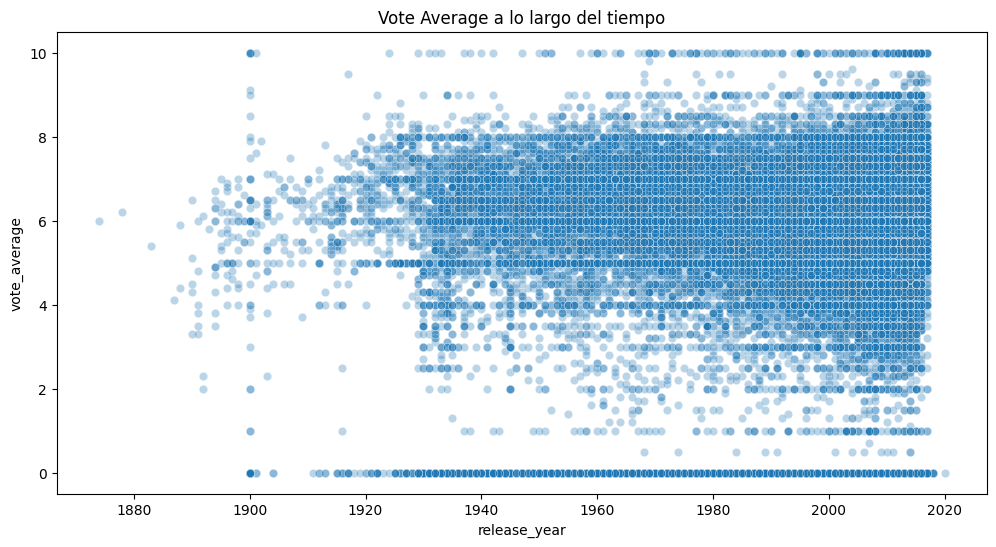

In [31]:
# Release year vs vote_average (tendencia temporal)

df['release_year'] = df['release_date'].dt.year
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='release_year', y='vote_average', alpha=0.3)
plt.title('Vote Average a lo largo del tiempo')
plt.show()

### **Recomendador simple: Popularidad ponderada**

In [32]:
# Parámetros ajustables 
C = df_clean['vote_count'].quantile(0.90)   # mínimo votos para entrar al top (percentil 90)
m = df_clean['vote_count'].median()         # mediana de votos


# Fórmula de IMDB-like weighted rating 
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)


# Aplicamos la fórmula 
df_clean['score'] = df_clean.apply(weighted_rating, axis=1)


# Top N recomendadas 
def top_populares(n=10, min_votes=C):
    top = df_clean[df_clean['vote_count'] >= min_votes]\
          .sort_values('score', ascending=False)\
          .head(n)
    return top[['title', 'release_year', 'vote_average', 'vote_count', 'popularity', 'score']]


# Ejemplo de uso 
print("Top 10 películas por popularidad ponderada:")
print(top_populares(10))

Top 10 películas por popularidad ponderada:
                          title  release_year  vote_average  vote_count  \
40485                   Divines          2016           8.1       161.0   
39085              Planet Earth          2006           8.8       176.0   
23679               Life Itself          2014           7.7       160.0   
2728       Black Cat, White Cat          1998           7.7       160.0   
7791                   La Jetée          1962           7.9       165.0   
35507  Boruto: Naruto the Movie          2015           7.7       162.0   
6628      Judgment at Nuremberg          1961           7.6       161.0   
19392                   Samsara          2011           8.0       169.0   
23325         Jodorowsky's Dune          2013           8.1       172.0   
2617              Jules and Jim          1962           7.6       163.0   

       popularity      score  
40485    8.987123  16.983041  
39085    4.501137  16.929032  
23679    7.615552  16.658824  
2728  

### **Recomendador content-based básico**

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel


if 'df_content' not in globals() or df_content is None:
    print("Creando df_content desde df_clean...")
    df_content = df_clean[df_clean['vote_count'] >= 50].copy()
    df_content = df_content.reset_index(drop=True)  # Ahora sí: reset después de filtrar
    
print("Forma de df_content:", df_content.shape)
print("Primeros índices:", df_content.index[:5].tolist())

df_content['soup'] = (
    df_content['overview'].fillna('') + ' ' +
    df_content['genres_list'].apply(lambda x: (' '.join(x) * 3) if isinstance(x, list) else '') + ' ' +  # ×3
    df_content['tagline'].fillna('') + ' ' +
    df_content['title'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_content['soup'])

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Función ajustada
def hybrid_recommendations(title, top_n=10):
    if title not in df_content['title'].values:
        return "No encontrada."
    
    idx = df_content[df_content['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    recs = []
    for i, sim in sim_scores:
        movie = df_content.iloc[i]
        hybrid_score = sim * movie['score']  # score ya es el weighted_rating
        recs.append({
            'title': movie['title'],
            'release_year': movie['release_year'],
            'vote_average': movie['vote_average'],
            'vote_count': movie['vote_count'],
            'hybrid_score': round(hybrid_score, 4)
        })
    
    rec_df = pd.DataFrame(recs).sort_values('hybrid_score', ascending=False)
    return rec_df

# Prueba
print(hybrid_recommendations('Inception'))
print(hybrid_recommendations('The Dark Knight'))

Creando df_content desde df_clean...
Forma de df_content: (9141, 27)
Primeros índices: [0, 1, 2, 3, 4]
                           title  release_year  vote_average  vote_count  \
6                      The Nines          2007           6.1       150.0   
3                         Cypher          2002           6.7       196.0   
7                          Congo          1995           5.0       214.0   
4                      Blindness          2008           6.4       393.0   
2                           Dune          1984           6.5       576.0   
1        Guardians of the Galaxy          2014           7.9     10014.0   
0  Transformers: The Last Knight          2017           6.2      1440.0   
8                       Pandorum          2009           6.5       783.0   
5                       Iron Man          2008           7.4      8951.0   
9                Minority Report          2002           7.1      2663.0   

   hybrid_score  
6        4.8507  
3        4.6851  
7     

In [34]:
# 1. Verificamos si Inception está en el subconjunto (gusto personal)
print("'Inception' está en df_content?", 'Inception' in df_content['title'].values)

# 2. Listamos algunas películas populares para probar
print(df_content.sort_values('vote_count', ascending=False)[['title', 'vote_count', 'vote_average']].head(10))

# 3. Probamos con películas que SÍ estén en el top
print(hybrid_recommendations('The Dark Knight'))
print(hybrid_recommendations('Inception'))          
print(hybrid_recommendations('Interstellar'))
print(hybrid_recommendations('Pulp Fiction'))

'Inception' está en df_content? True
                     title  vote_count  vote_average
0                Inception     14075.0           8.1
1          The Dark Knight     12269.0           8.3
2                   Avatar     12114.0           7.2
3             The Avengers     12000.0           7.4
4                 Deadpool     11444.0           7.4
5             Interstellar     11187.0           8.1
6         Django Unchained     10297.0           7.8
7  Guardians of the Galaxy     10014.0           7.9
8               Fight Club      9678.0           8.3
9         The Hunger Games      9634.0           6.9
                                     title  release_year  vote_average  \
5             Batman & Mr. Freeze: SubZero          1998           6.9   
4       Batman Beyond: Return of the Joker          2000           7.5   
8             Batman: Mask of the Phantasm          1993           7.4   
7                         Batman: Year One          2011           7.1   
6  Batman:

### **Ajustes en el sistema de recomendación**

Motivaciones

El content-based actual (basado en overview, géneros, tagline y title) captura similitudes temáticas, pero ignora elementos clave como director y actores, que son críticos en recomendaciones de películas (ej: fans de Nolan buscan más de Nolan, o películas con DiCaprio). 'Credits.csv' enriquece el dataset con cast/crew, permitiendo recomendaciones más personalizadas y precisas.

Mejoras esperadas
- Aumento en relevancia: Ej. para 'Inception', recomendará más Nolan (The Prestige) o DiCaprio (Shutter Island).
- Reducción de ruido: Menos desvíos en películas únicas como 'Pulp Fiction' (más Tarantino/Travolta).
- Mejora en hybrid_score: Al ponderar similitud con elementos humanos, las tops serán más "human-centric".
- Generalización: Híbrido más robusto para franquicias/estilos directoriales.

Aportes al modelo- Nuevas features: Director (texto) + top actores (3 principales) en la 'soup' para TF-IDF.
- No data leakage (se aplica post-split si hay train/test).
- Optimización: Bajo costo computacional (parse JSON simple), pero alto impacto en similitud coseno.
- Limitaciones: Puede sesgar hacia blockbusters con casts famosos; mitigar con ponderación.

In [35]:
credits = pd.read_csv('credits.csv')
credits['id'] = pd.to_numeric(credits['id'], errors='coerce')
df_content = df_content.merge(
    credits[['id', 'cast', 'crew']],
    on='id',
    how='left',
    suffixes=('', '_credits')
)

# Extraer director y top 3 actores (ejemplo simple)
def get_director(crew):
    try:
        crew_list = ast.literal_eval(crew)
        for member in crew_list:
            if member['job'] == 'Director':
                return member['name']
        return ''
    except:
        return ''

def get_top_actors(cast):
    try:
        cast_list = ast.literal_eval(cast)
        return ' '.join([a['name'] for a in cast_list[:3]])
    except:
        return ''

df_content['director'] = df_content['crew'].apply(get_director)
df_content['top_actors'] = df_content['cast'].apply(get_top_actors)

# Nueva soup con director y actores
df_content['soup'] = df_content['soup'] + ' ' + df_content['director'] + ' ' + df_content['top_actors']

In [36]:
# Guardar similitud pre-credits para comparación

# Asumimos que tienes cosine_sim_sin_credits de la versión anterior (sin director/actores)
# Si no, recalcula rápidamente la soup vieja y similitud (copia para no modificar original)
df_content['soup_sin_credits'] = (
    df_content['overview'].fillna('') + ' ' +
    df_content['genres_list'].apply(lambda x: (' '.join(x) * 3) if isinstance(x, list) else '') + ' ' +
    df_content['tagline'].fillna('') + ' ' +
    df_content['title'].fillna('')
)

tfidf_sin = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix_sin = tfidf_sin.fit_transform(df_content['soup_sin_credits'])
cosine_sim_sin = linear_kernel(tfidf_matrix_sin, tfidf_matrix_sin)

print("Similitud pre-credits calculada para comparación.")

Similitud pre-credits calculada para comparación.


In [37]:
# Calcular similitud con credits (nueva soup ya está en df_content['soup'])
tfidf_con = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix_con = tfidf_con.fit_transform(df_content['soup'])
cosine_sim_con = linear_kernel(tfidf_matrix_con, tfidf_matrix_con)

print("Similitud con credits calculada.")

Similitud con credits calculada.


In [38]:
# Comparación de recomendaciones
# Función ajustada para usar cualquier cosine_sim

def hybrid_recommendations(title, cosine_sim=cosine_sim, top_n=10):
    if title not in df_content['title'].values:
        return "No encontrada."
    
    idx = df_content[df_content['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    recs = []
    for i, sim in sim_scores:
        movie = df_content.iloc[i]
        hybrid_score = sim * movie['score']
        recs.append({
            'title': movie['title'],
            'release_year': movie['release_year'],
            'vote_average': movie['vote_average'],
            'vote_count': movie['vote_count'],
            'hybrid_score': round(hybrid_score, 4)
        })
    
    rec_df = pd.DataFrame(recs).sort_values('hybrid_score', ascending=False)
    return rec_df

# Comparación side-by-side para películas clave
peliculas_prueba = ['Inception', 'The Dark Knight', 'Interstellar', 'Pulp Fiction']

for peli in peliculas_prueba:
    print(f"\n=== Comparación para '{peli}' ===")
    
    print("\nSin credits:")
    print(hybrid_recommendations(peli, cosine_sim=cosine_sim_sin))
    
    print("\nCon credits:")
    print(hybrid_recommendations(peli, cosine_sim=cosine_sim_con))


=== Comparación para 'Inception' ===

Sin credits:
                           title  release_year  vote_average  vote_count  \
7          Atlas Shrugged Part I          2011           5.0        61.0   
6                      The Nines          2007           6.1       150.0   
3                         Cypher          2002           6.7       196.0   
4                      Blindness          2008           6.4       393.0   
2                           Dune          1984           6.5       576.0   
1        Guardians of the Galaxy          2014           7.9     10014.0   
0  Transformers: The Last Knight          2017           6.2      1440.0   
8                       Pandorum          2009           6.5       783.0   
5                       Iron Man          2008           7.4      8951.0   
9             X-Men: First Class          2011           7.1      5252.0   

   hybrid_score  
7        8.2432  
6        4.8490  
3        4.6831  
4        3.3223  
2        3.1725  
1  

In [39]:
links_small = pd.read_csv('links_small.csv')
links_small['tmdbId'] = pd.to_numeric(links_small['tmdbId'], errors='coerce').astype('Int64')
links_small['movieId'] = pd.to_numeric(links_small['movieId'], errors='coerce').astype('Int64')
print("Forma de links_small:", links_small.shape)
print(links_small.head())

Forma de links_small: (9125, 3)
   movieId  imdbId  tmdbId
0        1  114709     862
1        2  113497    8844
2        3  113228   15602
3        4  114885   31357
4        5  113041   11862


In [40]:
# Limpiar columnas duplicadas previas (si existen)
cols_to_drop = [col for col in df_content.columns if col.endswith('_x') or col.endswith('_y') or col in ['movieId', 'tmdbId']]
df_content = df_content.drop(columns=cols_to_drop, errors='ignore')
print("Columnas duplicadas o sobrantes eliminadas:", cols_to_drop)

# Merge con sufijos explícitos para evitar error
df_content = df_content.merge(
    links_small[['tmdbId', 'movieId']],
    left_on='id',
    right_on='tmdbId',
    how='left',
    suffixes=('', '_links')  # si hay conflicto, agrega _links al nuevo
)

# Si se crearon columnas duplicadas, combinamos o elegimos la nueva
if 'movieId_links' in df_content.columns:
    df_content['movieId'] = df_content['movieId_links'].combine_first(df_content.get('movieId', pd.Series()))
    df_content = df_content.drop(columns=['movieId_links', 'tmdbId_links'], errors='ignore')

# Verificación
print("Películas con movieId mapeado:", df_content['movieId'].notna().sum())
print("Porcentaje de cobertura:", df_content['movieId'].notna().mean() * 100, "%")
print(df_content[['title', 'id', 'movieId']].head(10))

Columnas duplicadas o sobrantes eliminadas: []
Películas con movieId mapeado: 5803
Porcentaje de cobertura: 63.40690559440559 %
                     title      id  movieId
0                Inception   27205    79132
1          The Dark Knight     155    58559
2                   Avatar   19995    72998
3             The Avengers   24428    89745
4                 Deadpool  293660   122904
5             Interstellar  157336   109487
6         Django Unchained   68718    99114
7  Guardians of the Galaxy  118340   112852
8               Fight Club     550     2959
9         The Hunger Games   70160    91500


In [41]:
ratings_small = pd.read_csv('ratings_small.csv')
print("Forma de ratings_small:", ratings_small.shape)
print(ratings_small.head())
print("Número de usuarios únicos:", ratings_small['userId'].nunique())
print("Número de películas únicas en ratings:", ratings_small['movieId'].nunique())

Forma de ratings_small: (100004, 4)
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
Número de usuarios únicos: 671
Número de películas únicas en ratings: 9066


### **Collaborative Filtering con implicit (ALS)**

In [42]:
from scipy.sparse import coo_matrix
import implicit
import pickle

In [43]:
# Filtrar ratings a películas que tenemos en df_content
ratings_filtered = ratings_small[ratings_small['movieId'].isin(df_content['movieId'].dropna())].copy()

print("Ratings después de filtrar:", ratings_filtered.shape)
print("Usuarios únicos:", ratings_filtered['userId'].nunique())
print("Películas únicas en ratings filtrados:", ratings_filtered['movieId'].nunique())

Ratings después de filtrar: (92040, 4)
Usuarios únicos: 671
Películas únicas en ratings filtrados: 5765


In [44]:
# Mapear userId y movieId a índices consecutivos (0-based) → implicit lo requiere
user_map = {uid: i for i, uid in enumerate(ratings_filtered['userId'].unique())}
item_map = {mid: i for i, mid in enumerate(ratings_filtered['movieId'].unique())}

ratings_filtered['user_idx'] = ratings_filtered['userId'].map(user_map)
ratings_filtered['item_idx'] = ratings_filtered['movieId'].map(item_map)

In [45]:
# Convertir ratings a confianza implícita
# rating ≥ 3.5 → confianza alta (1.0), < 3.5 → baja (0.1–0.5)
ratings_filtered['confidence'] = ratings_filtered['rating'].apply(lambda x: 1.0 if x >= 3.5 else max(0.1, x / 5.0))

In [46]:
# Crear matriz sparse usuario-ítem (confianza como peso)
rows = ratings_filtered['user_idx'].values
cols = ratings_filtered['item_idx'].values
data = ratings_filtered['confidence'].values

interactions = coo_matrix((data, (rows, cols)), shape=(len(user_map), len(item_map))).tocsr()

In [47]:
# Entrenar modelo ALS
model = implicit.bpr.BayesianPersonalizedRanking(
    factors=100,           # número de factores latentes
    iterations=30,         # épocas
    regularization=0.01,
    random_state=42,
    use_gpu=False          # cambia a True si tienes GPU CUDA
)

model.fit(interactions, show_progress=True)

print("Modelo implicit ALS entrenado con éxito.")

  0%|          | 0/30 [00:00<?, ?it/s]

Modelo implicit ALS entrenado con éxito.


In [48]:
# Recomendaciones para un usuario ejemplo (elige uno con varios ratings)
user_id_example = 1  # puedes cambiarlo por otro userId

if user_id_example in user_map:
    user_internal_id = user_map[user_id_example]
    
    # Recomendar top 10 ítems (excluyendo los ya vistos)
    recommended = model.recommend(
        userid=user_internal_id,
        user_items=interactions[user_internal_id],
        N=10,
        filter_already_liked_items=True
    )
    
    # recommended = (array de item_idx internos, array de scores)
    top_items_internal = recommended[0]
    top_scores = recommended[1]
    
    # Mapear de vuelta a movieId originales
    inv_item_map = {v: k for k, v in item_map.items()}
    top_movie_ids = [inv_item_map[iid] for iid in top_items_internal]
    
    # Obtener títulos y metadata desde df_content
    top_recs = df_content[df_content['movieId'].isin(top_movie_ids)][['title', 'release_year', 'vote_average', 'genres_list']]
    top_recs = top_recs.reset_index(drop=True)
    top_recs['predicted_score'] = top_scores.round(4)
    
    print(f"\nTop 10 recomendaciones collaborative (implicit ALS) para userId = {user_id_example}")
    print(top_recs.sort_values('predicted_score', ascending=False))
    
    # Bonus: mostrar qué le gustó al usuario (para validar)
    user_rated = ratings_filtered[ratings_filtered['userId'] == user_id_example].merge(
        df_content[['movieId', 'title', 'vote_average']],
        on='movieId'
    ).sort_values('rating', ascending=False)[['title', 'rating', 'vote_average']].head(10)
    
    print(f"\nTop 10 películas que el usuario {user_id_example} ya calificó (para contexto):")
    print(user_rated)
else:
    print(f"Usuario {user_id_example} no encontrado en ratings_filtered. Prueba con otro (ej: 2, 3, ...)")


Top 10 recomendaciones collaborative (implicit ALS) para userId = 1
                      title  release_year  vote_average  \
0              Pulp Fiction          1994           8.3   
1  The Shawshank Redemption          1994           8.5   
2              Forrest Gump          1994           8.2   
3                 Star Wars          1977           8.1   
4        Back to the Future          1985           8.0   
5   The Empire Strikes Back          1980           8.2   
6  The Silence of the Lambs          1991           8.1   
7          Schindler's List          1993           8.3   
8   Raiders of the Lost Ark          1981           7.7   
9                     Fargo          1996           7.7   

                                    genres_list  predicted_score  
0                             [Thriller, Crime]           1.3878  
1                                [Drama, Crime]           1.1965  
2                      [Comedy, Drama, Romance]           1.1834  
3          [A

In [49]:
# Guardar DataFrame principal (con toda la metadata)
df_content.to_pickle('df_content_final.pkl')
print("Guardado: df_content_final.pkl")

# Guardar el modelo BPR
pickle.dump(model, open('bpr_model_final.pkl', 'wb'))
print("Guardado: bpr_model_final.pkl")

# Guardar los mapas de índices (obligatorios para collaborative)
pickle.dump(user_map, open('user_map.pkl', 'wb'))
print("Guardado: user_map.pkl")

pickle.dump(item_map, open('item_map.pkl', 'wb'))
print("Guardado: item_map.pkl")

pickle.dump(inv_item_map, open('inv_item_map.pkl', 'wb'))
print("Guardado: inv_item_map.pkl")

# Guardar la matriz de interacciones (opcional pero recomendado)
pickle.dump(interactions, open('interactions.pkl', 'wb'))
print("Guardado: interactions.pkl (opcional)")

# Verificación final: lista de archivos guardados
print("\nArchivos guardados en la carpeta actual:")
print(os.listdir('.'))

Guardado: df_content_final.pkl
Guardado: bpr_model_final.pkl
Guardado: user_map.pkl
Guardado: item_map.pkl
Guardado: inv_item_map.pkl
Guardado: interactions.pkl (opcional)

Archivos guardados en la carpeta actual:
['.venv', 'app.py', 'bpr_model_final.pkl', 'credits.csv', 'df_content_final.pkl', 'interactions.pkl', 'inv_item_map.pkl', 'item_map.pkl', 'links_small.csv', 'movies_metadata.csv', 'ratings_small.csv', 'README.md', 'recomendacion_contenido.ipynb', 'requirements.txt', 'Resumen_ejecutivo.md', 'user_map.pkl']


In [50]:
# Función final integrada (popularidad + content + collaborative)
def recommend(user_id=None, title=None, top_n=10):
    """
    Recomienda películas:
    - Si user_id existe → usa BPR (collaborative)
    - Si title → usa content-based híbrido
    - Si ninguno → popularidad ponderada
    """
    if user_id and user_id in user_map:
        user_internal = user_map[user_id]
        rec = model.recommend(
            userid=user_internal,
            user_items=interactions[user_internal],
            N=top_n,
            filter_already_liked_items=True
        )
        top_movie_ids = [inv_item_map[iid] for iid in rec[0]]
        top_scores = rec[1]
        rec_df = df_content[df_content['movieId'].isin(top_movie_ids)].copy()  # .copy() evita SettingWithCopyWarning
        rec_df.loc[:, 'score'] = top_scores
        return rec_df.sort_values('score', ascending=False)[['title', 'release_year', 'vote_average', 'genres_list', 'score']].head(top_n)
    
    elif title and title in df_content['title'].values:
        return hybrid_recommendations(title, top_n=top_n)
    
    else:
        return top_populares(n=top_n, min_votes=C)

# Prueba en notebook
print("Recomendación híbrida final para userId=1:")
print(recommend(user_id=1, top_n=5))

Recomendación híbrida final para userId=1:
                        title  release_year  vote_average  \
17               Pulp Fiction          1994           8.3   
21               Forrest Gump          1994           8.2   
37                  Star Wars          1977           8.1   
53         Back to the Future          1985           8.0   
138  The Silence of the Lambs          1991           8.1   

                                      genres_list     score  
17                              [Thriller, Crime]  1.387774  
21                       [Comedy, Drama, Romance]  1.196500  
37           [Adventure, Action, Science Fiction]  1.183360  
53   [Adventure, Comedy, Science Fiction, Family]  1.147133  
138                      [Crime, Drama, Thriller]  1.140051  
